In [1]:
import matplotlib
import pandas as pd
from pathlib import Path

file_path = Path("NHTSA/COMPLAINTS_RECEIVED_2025-2026.txt")

In [2]:
column_names = [
    "CMPLID",            # 1  - NHTSA internal unique sequence number
    "ODINO",             # 2  - NHTSA internal reference number
    "MFR_NAME",          # 3  - Manufacturer's name
    "MAKETXT",           # 4  - Vehicle/equipment make
    "MODELTXT",          # 5  - Vehicle/equipment model
    "YEARTXT",           # 6  - Model year (9999 if unknown/N/A)
    "CRASH",             # 7  - Was vehicle involved in a crash (Y/N)
    "FAILDATE",          # 8  - Date of incident (YYYYMMDD)
    "FIRE",              # 9  - Was vehicle involved in a fire (Y/N)
    "INJURED",           # 10 - Number of persons injured
    "DEATHS",            # 11 - Number of fatalities
    "COMPDESC",          # 12 - Specific component description
    "CITY",              # 13 - Consumer's city
    "STATE",             # 14 - Consumer's state code
    "VIN",               # 15 - Vehicle's VIN
    "DATEA",             # 16 - Date added to file (YYYYMMDD)
    "LDATE",             # 17 - Date complaint received by NHTSA (YYYYMMDD)
    "MILES",             # 18 - Vehicle mileage at failure
    "OCCURENCES",        # 19 - Number of occurrences
    "CDESCR",            # 20 - Description of the complaint
    "CMPL_TYPE",         # 21 - Source of complaint code
    "POLICE_RPT_YN",     # 22 - Was incident reported to police (Y/N)
    "PURCH_DT",          # 23 - Date purchased (YYYYMMDD)
    "ORIG_OWNER_YN",     # 24 - Was original owner (Y/N)
    "ANTI_BRAKES_YN",    # 25 - Anti-lock brakes (Y/N)
    "CRUISE_CONT_YN",    # 26 - Cruise control (Y/N)
    "NUM_CYLS",          # 27 - Number of cylinders
    "DRIVE_TRAIN",       # 28 - Drive train type (AWD/4WD/FWD/RWD)
    "FUEL_SYS",          # 29 - Fuel system code (FI/TB)
    "FUEL_TYPE",         # 30 - Fuel type code (BF/CN/DS/GS/HE)
    "TRANS_TYPE",        # 31 - Transmission type (AUTO/MAN)
    "VEH_SPEED",         # 32 - Vehicle speed
    "DOT",               # 33 - DOT tire identifier
    "TIRE_SIZE",         # 34 - Tire size
    "LOC_OF_TIRE",       # 35 - Location of tire code
    "TIRE_FAIL_TYPE",    # 36 - Type of tire failure code
    "ORIG_EQUIP_YN",     # 37 - Was part original equipment (Y/N)
    "MANUF_DT",          # 38 - Date of manufacture (YYYYMMDD)
    "SEAT_TYPE",         # 39 - Type of child seat code
    "RESTRAINT_TYPE",    # 40 - Installation system code
    "DEALER_NAME",       # 41 - Dealer's name
    "DEALER_TEL",        # 42 - Dealer's telephone number
    "DEALER_CITY",       # 43 - Dealer's city
    "DEALER_STATE",      # 44 - Dealer's state code
    "DEALER_ZIP",        # 45 - Dealer's zipcode
    "PROD_TYPE",         # 46 - Product type code (V/T/E/C)
    "REPAIRED_YN",       # 47 - Was defective tire repaired (Y/N)
    "MEDICAL_ATTN",      # 48 - Was medical attention required (Y/N)
    "VEHICLES_TOWED_YN", # 49 - Was vehicle towed (Y/N)
]

In [3]:
def load_df():
    # Read tab-delimited file with no header row; assign column names from data dictionary
    df = pd.read_csv(
        file_path,
        sep="\t",
        header=None,
        names=column_names,
        dtype=str,           # Read all as strings initially to avoid type coercion issues
        encoding="latin-1",  # NHTSA files often use latin-1 encoding
    )

    # Convert numeric columns to appropriate types
    numeric_cols = {
        "YEARTXT": "Int64",
        "INJURED": "Int64",
        "DEATHS": "Int64",
        "MILES": "Int64",
        "OCCURENCES": "Int64",
        "NUM_CYLS": "Int64",
        "VEH_SPEED": "Int64",
    }
    for col, dtype in numeric_cols.items():
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(dtype)

    # Convert date columns from YYYYMMDD strings to datetime objects
    date_cols = ["FAILDATE", "DATEA", "LDATE", "PURCH_DT", "MANUF_DT"]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], format="%Y%m%d", errors="coerce")
    return df

In [4]:
df = load_df()

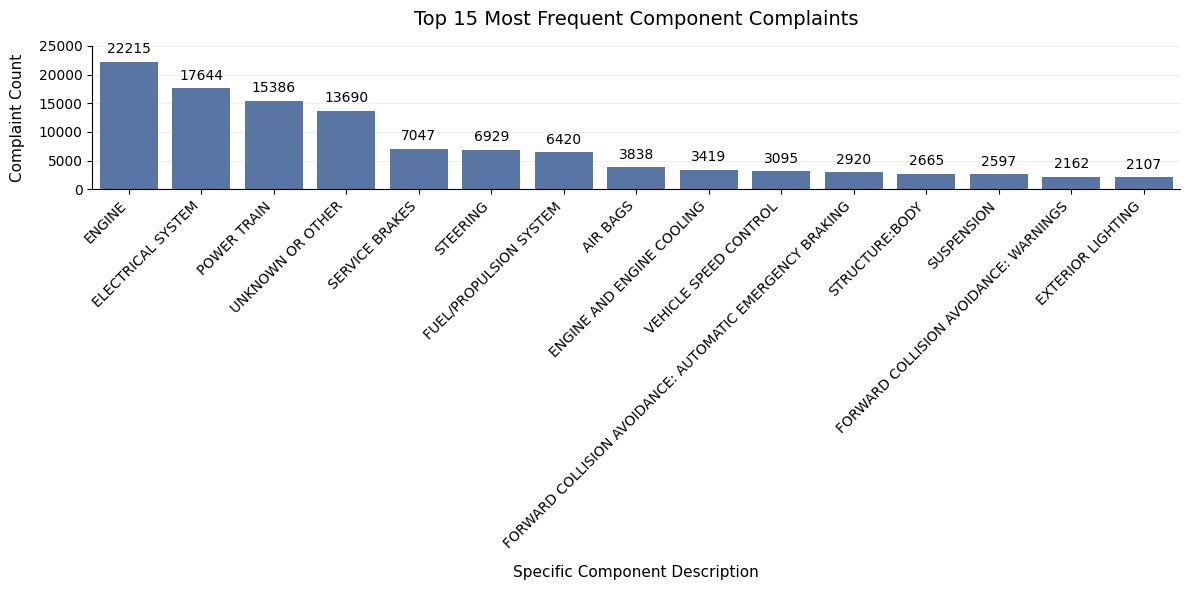

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Handle missing values in column 12 (COMPDESC) and get top 15 categories
top_complaints = df['COMPDESC'].fillna('Unknown').value_counts().head(15)

# Set up the figure (Tufte/Few principles: minimal ink, clear presentation)
fig, ax = plt.subplots(figsize=(12, 6))

# Use a muted, single color to avoid unnecessary cognitive load
barplot = sns.barplot(x=top_complaints.index, y=top_complaints.values, ax=ax, color='#4C72B0')

# Minimize data-ink ratio by removing unnecessary spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Keep grid minimal: light horizontal lines only to help track numbering
ax.yaxis.grid(True, linestyle='-', color='#EAEAEA', alpha=0.8)
ax.set_axisbelow(True)

# Clear and direct labels
ax.set_xlabel('Specific Component Description', fontsize=11, labelpad=10)
ax.set_ylabel('Complaint Count', fontsize=11, labelpad=10)
ax.set_title('Top 15 Most Frequent Component Complaints', fontsize=14, pad=15)

# Rotate X-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add black data labels above each bar for precision (Stephen Few principle)
for p in ax.patches:
    ax.annotate(format(int(p.get_height()), 'd'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   color='black', fontsize=10)

# Programmatically set Y-axis limit to ensure it reaches above the largest bar
# by rounding up to the next full 5000 count interval.
max_val = top_complaints.max()
tick_interval = 5000
upper_limit = math.ceil((max_val * 1.05) / tick_interval) * tick_interval
ax.set_ylim(0, upper_limit)

# Prevent labels from being cut off
plt.tight_layout()

# Display chart inline
plt.show()


## Top Vehicles by Complaint Count (Make · Model · Year)

This chart groups every complaint in the dataset by the combination of **Make**, **Model**, and **Year** (columns `MAKETXT`, `MODELTXT`, `YEARTXT`) and counts how many complaints share each combination.

The top 30 Make/Model/Year combinations are displayed as a **horizontal bar chart**, sorted so the most-complained vehicle appears at the top. Bar lengths encode complaint volume directly; count labels at each bar tip eliminate the need to interpolate from the axis.

Design follows Tufte / Few principles: minimal non-data ink (spines removed, no bar outlines), a single neutral color to avoid unnecessary categorical encoding, and subtle reference gridlines to assist magnitude comparison without competing with the data.

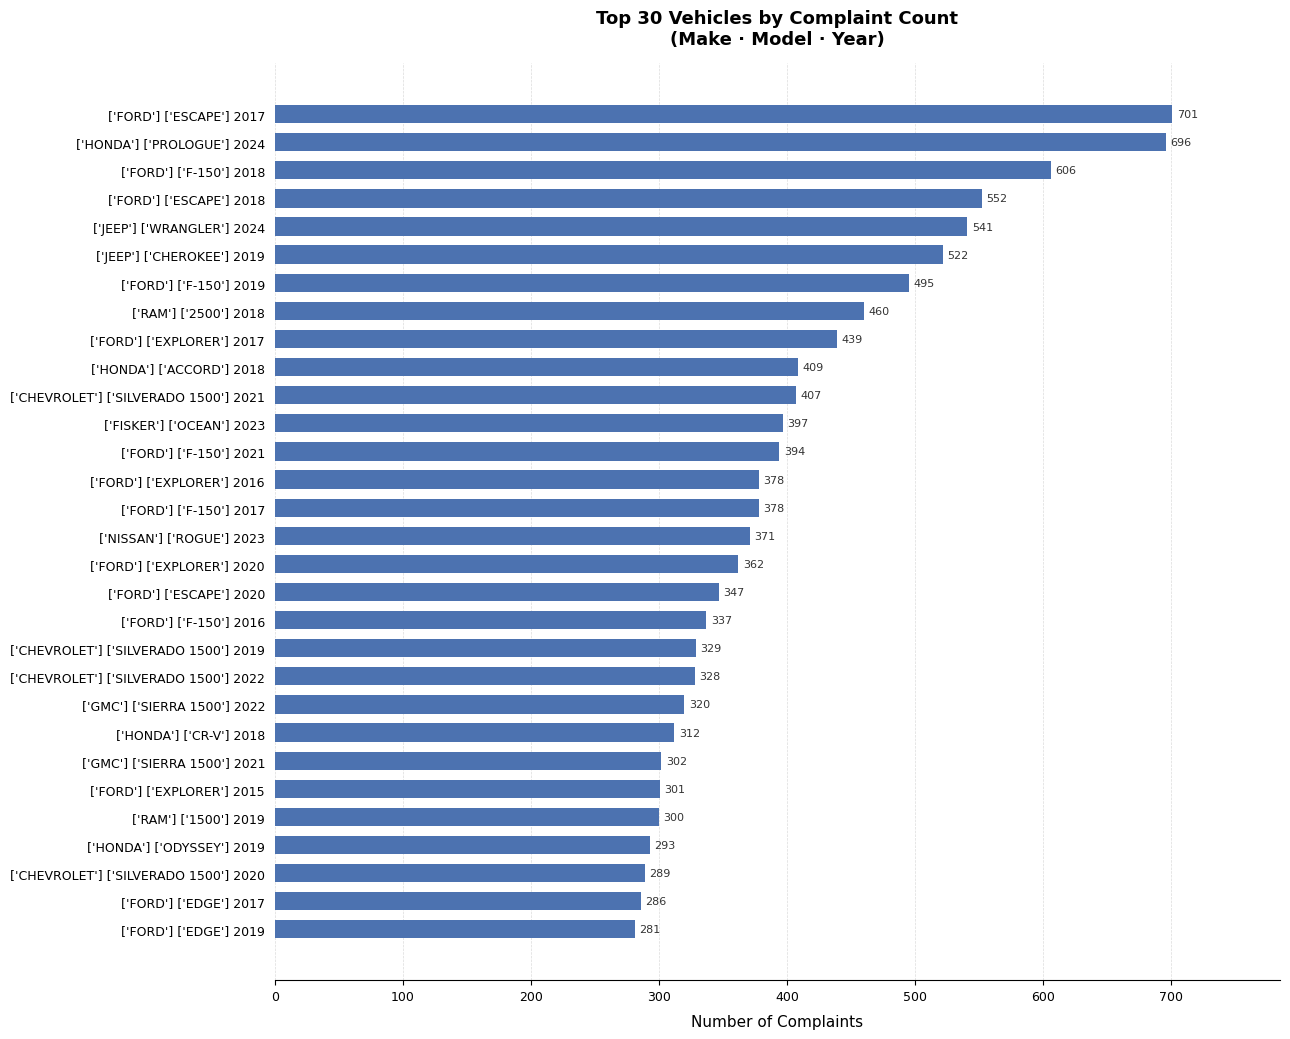

In [6]:
import sys
sys.path.insert(0, "Project_Tools")

from Create_Charts import create_model_year_chart

create_model_year_chart("NHTSA/complaints_cleaned.parquet", include_year = True)

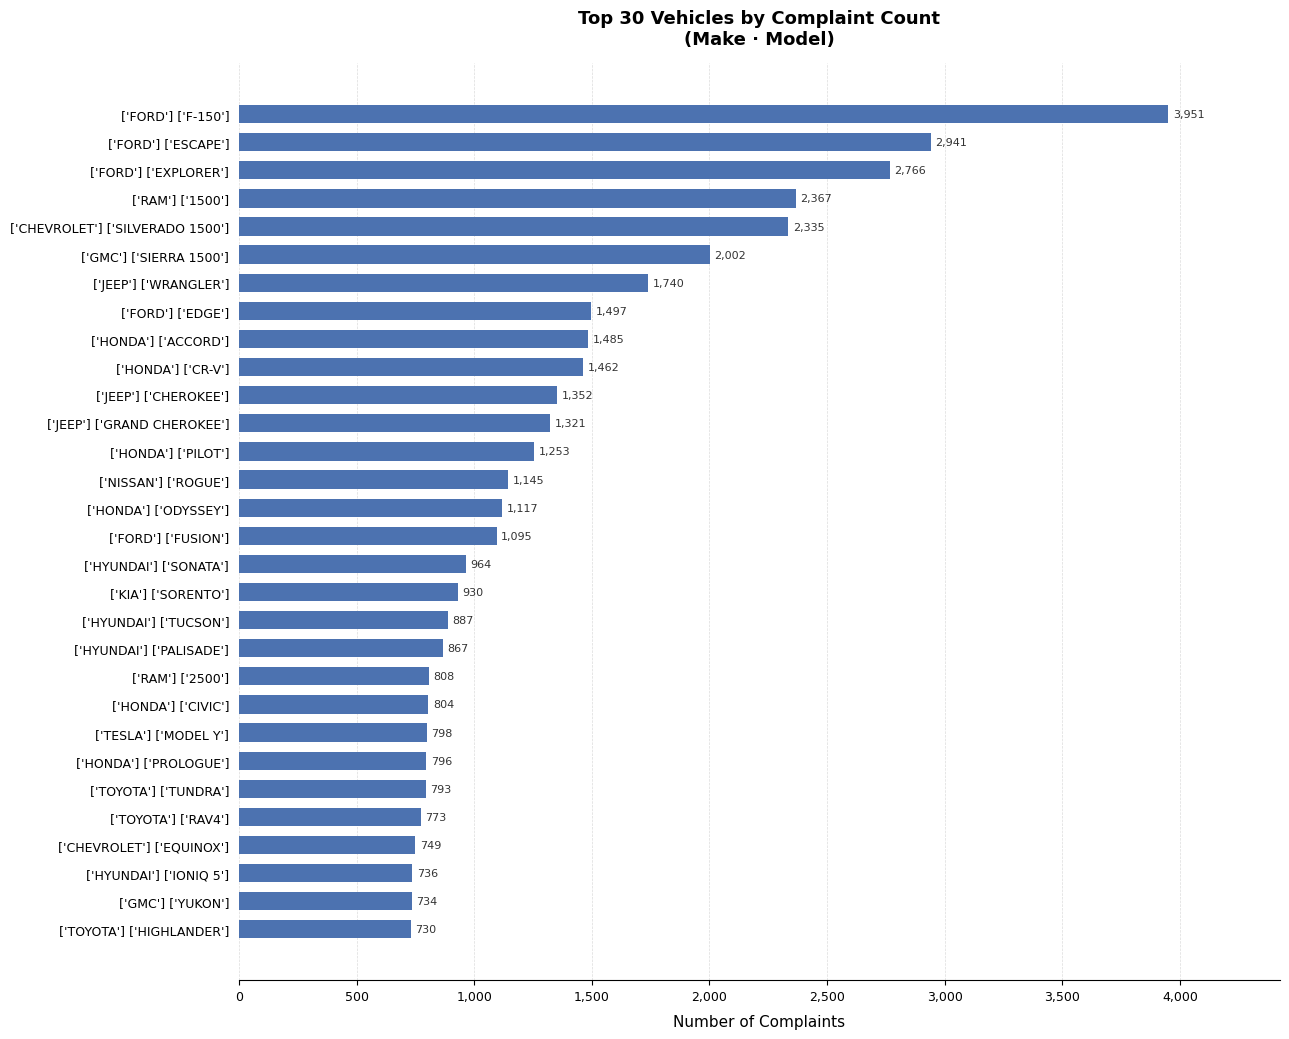

In [7]:
from Create_Charts import create_model_year_chart

create_model_year_chart("NHTSA/complaints_cleaned.parquet")